# PASSO 3 - Treinamento de Modelo (Árvore de Decisão)
Nesse passo, vamos treinar modelos de Árvore de Decisão para cada traço de personalidade MBTI.

## 0. Setup
Importar os pacotes necessários para rodar o resto do código.

In [20]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from pipeline.smote_oversampling import SMOTEOversampler
from pipeline.utils.extras import divide_mbti
from pipeline.machine_learning_algorithms.decision_tree import DecisionTree

# Tamanho do subset humano original no passo 2 (antes da augmentação por SLM).
# Validado em cada experimento "base" para garantir que o fatiamento [:N_HUMAN_POSTS]
# realmente corresponde aos posts humanos e não inclui amostras augmentadas.
N_HUMAN_POSTS = 6940
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train_datasets"
TEST_DIR = DATA_DIR / "test_datasets"
MODELS_DIR = Path("models/decision_tree")
DT_PARAMS = dict(max_depth=8, min_samples_split=5, random_state=42)

def load_train_test(embedding):
    """Carrega x_train/x_test (para um embedding) e y_train/y_test (comuns a todos)."""
    x_train = pd.read_pickle(TRAIN_DIR / f"x_train_{embedding}.pkl")
    x_test = pd.read_pickle(TEST_DIR / f"x_test_{embedding}.pkl")
    y_train = pd.Series(pd.read_pickle(TRAIN_DIR / "y_train.pkl"))
    y_test = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
    return x_train, x_test, y_train, y_test

def load_train_test_gpt2(embedding):
    """Carrega x_train/x_test (para um embedding) e y_train/y_test com augmentação GPT-2."""
    x_train = pd.read_pickle(TRAIN_DIR / f"x_train_{embedding}_gpt2.pkl")
    x_test = pd.read_pickle(TEST_DIR / f"x_test_{embedding}.pkl")
    y_train = pd.Series(pd.read_pickle(TRAIN_DIR / "y_train.pkl"))
    y_test = pd.Series(pd.read_pickle(TEST_DIR / "y_test.pkl"))
    return x_train, x_test, y_train, y_test

def save_models(clf, label):
    """Salva os 4 submodelos (um por traço MBTI) com sufixo `label`."""
    for key, model in clf.models.items():
        path = MODELS_DIR / f"{key}_{label}.pkl"
        path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(model, path)
        print(f"Salvo: {path}")

def run_experiment(embedding, label, *, use_smote=True, human_only=False):
    """Carrega dados, (opcionalmente) aplica SMOTE, treina, avalia e salva os modelos.
    - `human_only=True`: restringe o treino aos posts humanos originais (sem augmentação SLM).
    - `use_smote=False`: não aplica oversampling (baseline sem SMOTE).
    Retorna o classificador treinado (predições ficam disponíveis via clf.predict)."""
    x_train, x_test, y_train, y_test = load_train_test(embedding)

    if human_only:
        assert len(x_train) >= N_HUMAN_POSTS, (
            f"x_train ({len(x_train)}) menor que N_HUMAN_POSTS ({N_HUMAN_POSTS}); "
            "verifique a ordem de concatenação no passo 2."
        )
        x_train = x_train[:N_HUMAN_POSTS]
        y_train = y_train[:N_HUMAN_POSTS]

    if use_smote:
        x_train, y_train = SMOTEOversampler(random_state=42).fit_resample(x_train, y_train)

    y_train_4cols = divide_mbti(y_train)
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

    clf = DecisionTree(**DT_PARAMS)
    clf.fit(x_train, y_train_4cols)
    clf.evaluate(x_test, y_test_4cols)
    save_models(clf, label)
    return clf

def run_experiment_gpt2(embedding, label, *, use_smote=True, human_only=False):
    """Carrega dados com augmentação GPT-2, (opcionalmente) aplica SMOTE, treina, avalia e salva os modelos.
    - `human_only=True`: restringe o treino aos posts humanos originais (sem augmentação SLM).
    - `use_smote=False`: não aplica oversampling (baseline sem SMOTE).
    Retorna o classificador treinado (predições ficam disponíveis via clf.predict)."""
    x_train, x_test, y_train, y_test = load_train_test_gpt2(embedding)

    if human_only:
        assert len(x_train) >= N_HUMAN_POSTS, (
            f"x_train ({len(x_train)}) menor que N_HUMAN_POSTS ({N_HUMAN_POSTS}); "
            "verifique a ordem de concatenação no passo 2."
        )
        x_train = x_train[:N_HUMAN_POSTS]
        y_train = y_train[:N_HUMAN_POSTS]

    if use_smote:
        x_train, y_train = SMOTEOversampler(random_state=42).fit_resample(x_train, y_train)

    y_train_4cols = divide_mbti(y_train)
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

    clf = DecisionTree(**DT_PARAMS)
    clf.fit(x_train, y_train_4cols)
    clf.evaluate(x_test, y_test_4cols)
    save_models(clf, label)
    return clf

## 1. Baseline
Treina apenas com os posts humanos originais, sem aplicação de técnicas de balanceamento de classes. Serve como parâmetro de controle para avaliar o ganho das otimizações posteriores.

#### TF-IDF

In [21]:
tfidf_baseline = run_experiment('tfidf', 'tfidf_baseline', use_smote=False, human_only=True)

Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7631

              precision    recall  f1-score   support

           0       0.48      0.28      0.35       401
           1       0.81      0.91      0.85      1334

    accuracy                           0.76      1735
   macro avg       0.64      0.59      0.60      1735
weighted avg       0.73      0.76      0.74      1735


Evaluation for dimension: N_S
Accuracy: 0.8536

              precision    recall  f1-score   support

           0       0.41      0.14      0.21       240
           1       0.87      0.97      0.92      1495

    accuracy                           0.85      1735
   macro avg       0.64      0.55      0.56      1735
weighted avg       0.81      0.85      0.82      1735


Evaluation for dimens

#### Word2Vec

In [22]:
w2v_baseline = run_experiment('w2v', 'w2v_baseline', use_smote=False, human_only=True)

Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7095

              precision    recall  f1-score   support

           0       0.32      0.22      0.26       401
           1       0.79      0.86      0.82      1334

    accuracy                           0.71      1735
   macro avg       0.55      0.54      0.54      1735
weighted avg       0.68      0.71      0.69      1735


Evaluation for dimension: N_S
Accuracy: 0.8294

              precision    recall  f1-score   support

           0       0.25      0.12      0.16       240
           1       0.87      0.94      0.91      1495

    accuracy                           0.83      1735
   macro avg       0.56      0.53      0.53      1735
weighted avg       0.78      0.83      0.80      1735


Evaluation for dimens

## 2. Baseline + SMOTE
Treina com um over-sampling SMOTE dos dados originais. Gerando amostras sintéticas baseadas nas classes minoritárias, visando reduzir o viés do modelo.

#### TF-IDF

In [23]:
tfidf_smote = run_experiment('tfidf', 'tfidf_smote', use_smote=True, human_only=True)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7112

              precision    recall  f1-score   support

           0       0.38      0.40      0.39       401
           1       0.82      0.80      0.81      1334

    accuracy                           0.71      1735
   macro avg       0.60      0.60      0.60      1735
weighted avg       0.72      0.71      0.71      1735


Evaluation for dimension: N_S
Accuracy: 0.7614

              precision    recall  f1-score   support

           0       0.20      0.25      0.22       240
           1       0.87      0.84      0.86      1495

    accuracy                           0.76      1735
   macro avg       0.54   

#### Word2Vec

In [24]:
w2v_smote = run_experiment('w2v', 'w2v_smote', use_smote=True, human_only=True)

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.6012

              precision    recall  f1-score   support

           0       0.29      0.48      0.36       401
           1       0.80      0.64      0.71      1334

    accuracy                           0.60      1735
   macro avg       0.54      0.56      0.53      1735
weighted avg       0.68      0.60      0.63      1735


Evaluation for dimension: N_S
Accuracy: 0.6795

              precision    recall  f1-score   support

           0       0.20      0.45      0.28       240
           1       0.89      0.72      0.79      1495

    accuracy                           0.68      1735
   macro avg       0.55      0

## 3. Baseline + SMOTE + SLM (qwen)
Treina com um over-sampling e um augmentation de SLM (qwen) dos dados originais. O objetivo é testar se a variabilidade introduzida pela IA melhora a capacidade de generalização do modelo.

#### TF-IDF

In [25]:
tfidf_aug = run_experiment('tfidf', 'tfidf_qwen', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7510

              precision    recall  f1-score   support

           0       0.45      0.38      0.42       401
           1       0.82      0.86      0.84      1334

    accuracy                           0.75      1735
   macro avg       0.64      0.62      0.63      1735
weighted avg       0.74      0.75      0.74      1735


Evaluation for dimension: N_S
Accuracy: 0.8202

              precision    recall  f1-score   support

           0       0.31      0.25      0.27       240
           1       0.88      0.91      0.90      1495

    accuracy                           0.82      1735
   macro avg       0.60   

#### Word2Vec

In [26]:
w2v_aug = run_experiment('w2v', 'w2v_qwen', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.6403

              precision    recall  f1-score   support

           0       0.30      0.42      0.35       401
           1       0.80      0.71      0.75      1334

    accuracy                           0.64      1735
   macro avg       0.55      0.56      0.55      1735
weighted avg       0.69      0.64      0.66      1735


Evaluation for dimension: N_S
Accuracy: 0.6974

              precision    recall  f1-score   support

           0       0.19      0.35      0.24       240
           1       0.88      0.75      0.81      1495

    accuracy                           0.70      1735
   macro avg       0.53      0

## 3. Baseline + SMOTE + SLM (GPT-2)
Treina com um over-sampling e um augmentation de SLM (GPT-2) dos dados originais. O objetivo é testar se a variabilidade introduzida pela IA melhora a capacidade de generalização do modelo.

#### TF-IDF

In [27]:
tfidf_aug = run_experiment_gpt2('tfidf', 'tfidf_gpt2', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.6911

              precision    recall  f1-score   support

           0       0.23      0.15      0.18       401
           1       0.77      0.85      0.81      1334

    accuracy                           0.69      1735
   macro avg       0.50      0.50      0.50      1735
weighted avg       0.65      0.69      0.66      1735


Evaluation for dimension: N_S
Accuracy: 0.8329

              precision    recall  f1-score   support

           0       0.15      0.05      0.07       240
           1       0.86      0.96      0.91      1495

    accuracy                           0.83      1735
   macro avg       0.51   

#### Word2Vec

In [28]:
w2v_aug = run_experiment_gpt2('w2v', 'w2v_gpt2', use_smote=True, human_only=False)

Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅

Evaluation for dimension: I_E
Accuracy: 0.7585

              precision    recall  f1-score   support

           0       0.29      0.03      0.05       401
           1       0.77      0.98      0.86      1334

    accuracy                           0.76      1735
   macro avg       0.53      0.50      0.46      1735
weighted avg       0.66      0.76      0.67      1735


Evaluation for dimension: N_S
Accuracy: 0.1412

              precision    recall  f1-score   support

           0       0.14      0.99      0.24       240
           1       0.73      0.01      0.01      1495

    accuracy                           0.14      1735
   macro avg       0.43      0

## 4. Análise Comparativa
Avaliação da performance preditiva dos modelos, comparando os resultados das predições de cada experimento.

In [29]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import f1_score

MODELS_DIR = Path("models/decision_tree")
TEST_DIR = Path("data/test_datasets")

# ----------------------------
# Testes padrão (Base, SMOTE e Qwen)
# ----------------------------
with open(TEST_DIR / "x_test_tfidf.pkl", "rb") as f:
    X_test_tfidf = pickle.load(f)

with open(TEST_DIR / "x_test_w2v.pkl", "rb") as f:
    X_test_w2v = pickle.load(f)

with open(TEST_DIR / "y_test.pkl", "rb") as f:
    y_test_raw = pd.Series(pickle.load(f))

y_test_4cols = divide_mbti(y_test_raw)

# ----------------------------
# Testes GPT-2
# ----------------------------
with open(TEST_DIR / "x_test_tfidf_gpt2.pkl", "rb") as f:
    X_test_tfidf_gpt2 = pickle.load(f)

with open(TEST_DIR / "x_test_w2v_gpt2.pkl", "rb") as f:
    X_test_w2v_gpt2 = pickle.load(f)

with open(TEST_DIR / "y_test_gpt2.pkl", "rb") as f:
    y_test_raw_gpt2 = pd.Series(pickle.load(f))

y_test_4cols_gpt2 = divide_mbti(y_test_raw_gpt2)

In [30]:
def load_classifier(label):
    clf = DecisionTree(**DT_PARAMS)
    for dim in clf.dimensions:
        path = MODELS_DIR / f"{dim}_{label}.pkl"
        clf.models[dim] = joblib.load(path)
    print(f"Modelos com sufixo '{label}' carregados com sucesso! ✅")
    return clf

# ----------------------------
# Base (sem SMOTE)
# ----------------------------
clf_tfidf_base = load_classifier("tfidf_baseline")
clf_w2v_base   = load_classifier("w2v_baseline")

# ----------------------------
# Apenas SMOTE
# ----------------------------
clf_tfidf_smote = load_classifier("tfidf_smote")
clf_w2v_smote   = load_classifier("w2v_smote")

# ----------------------------
# Qwen + SMOTE
# ----------------------------
clf_tfidf_qwen = load_classifier("tfidf_qwen")
clf_w2v_qwen   = load_classifier("w2v_qwen")

# ----------------------------
# GPT-2 + SMOTE
# ----------------------------
clf_tfidf_gpt = load_classifier("tfidf_gpt2")
clf_w2v_gpt   = load_classifier("w2v_gpt2")

Modelos com sufixo 'tfidf_baseline' carregados com sucesso! ✅
Modelos com sufixo 'w2v_baseline' carregados com sucesso! ✅
Modelos com sufixo 'tfidf_smote' carregados com sucesso! ✅
Modelos com sufixo 'w2v_smote' carregados com sucesso! ✅
Modelos com sufixo 'tfidf_qwen' carregados com sucesso! ✅
Modelos com sufixo 'w2v_qwen' carregados com sucesso! ✅
Modelos com sufixo 'tfidf_gpt2' carregados com sucesso! ✅
Modelos com sufixo 'w2v_gpt2' carregados com sucesso! ✅


In [31]:
predictions = {
    "TF-IDF": {
        "1. Base (No SMOTE)": (
            clf_tfidf_base.predict(X_test_tfidf),
            y_test_4cols
        ),
        "2. SMOTE Only": (
            clf_tfidf_smote.predict(X_test_tfidf),
            y_test_4cols
        ),
        "3. Qwen + SMOTE": (
            clf_tfidf_qwen.predict(X_test_tfidf),
            y_test_4cols
        ),
        "4. GPT-2 + SMOTE": (
            clf_tfidf_gpt.predict(X_test_tfidf_gpt2),
            y_test_4cols_gpt2
        ),
    },

    "Word2Vec": {
        "1. Base (No SMOTE)": (
            clf_w2v_base.predict(X_test_w2v),
            y_test_4cols
        ),
        "2. SMOTE Only": (
            clf_w2v_smote.predict(X_test_w2v),
            y_test_4cols
        ),
        "3. Qwen + SMOTE": (
            clf_w2v_qwen.predict(X_test_w2v),
            y_test_4cols
        ),
        "4. GPT-2 + SMOTE": (
            clf_w2v_gpt.predict(X_test_w2v_gpt2),
            y_test_4cols_gpt2
        ),
    }
}

colunas = ['I_E', 'N_S', 'T_F', 'J_P']
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']

dados = []

for emb, modelos in predictions.items():
    for metodo, (pred, y_true) in modelos.items():
        for eixo, nome in zip(colunas, nomes_eixos):
            dados.append({
                "Embedding": emb,
                "Axis": nome,
                "Method": metodo,
                "F1 (%)": 100 * f1_score(
                    y_true[eixo],
                    pred[eixo],
                    average="weighted",
                    zero_division=0
                )
            })

df_plot = pd.DataFrame(dados)

,Embedding,Axis,Method,F1 (%)
0,TF-IDF,I/E\n(Introvert/Extravert),1. Base (No SMOTE),73.933071
1,TF-IDF,N/S\n(Intuition/Sensing),1. Base (No SMOTE),82.072092
2,TF-IDF,T/F\n(Thinking/Feeling),1. Base (No SMOTE),68.417594
3,TF-IDF,J/P\n(Judging/Perceiving),1. Base (No SMOTE),64.886152
4,TF-IDF,I/E\n(Introvert/Extravert),2. SMOTE Only,71.377782
5,TF-IDF,N/S\n(Intuition/Sensing),2. SMOTE Only,77.093335
6,TF-IDF,T/F\n(Thinking/Feeling),2. SMOTE Only,60.475969
7,TF-IDF,J/P\n(Judging/Perceiving),2. SMOTE Only,56.548534
8,TF-IDF,I/E\n(Introvert/Extravert),3. Qwen + SMOTE,74.340530
9,TF-IDF,N/S\n(Intuition/Sensing),3. Qwen + SMOTE,81.119669


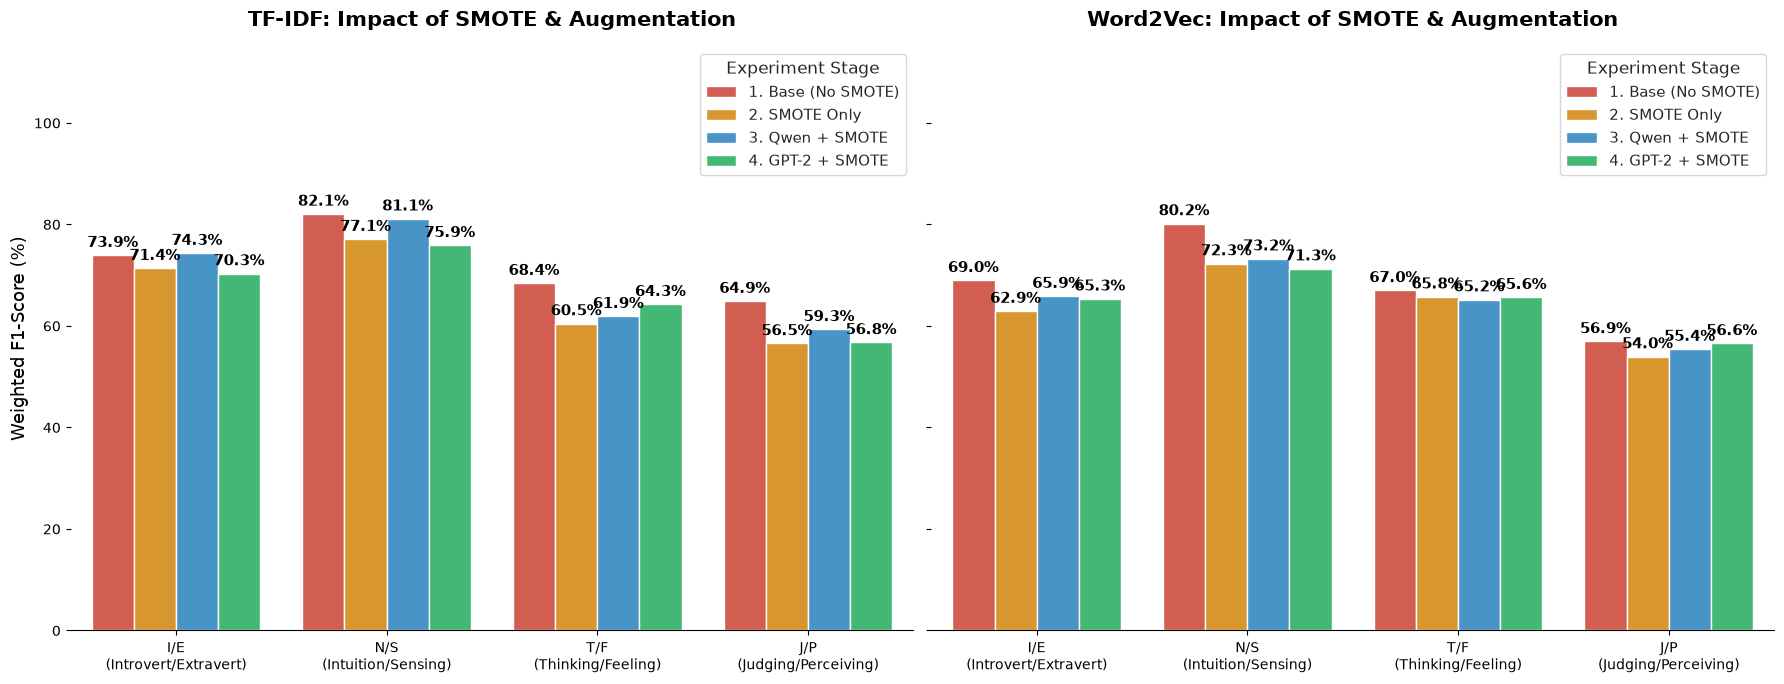

In [32]:
# Exibindo os resultados tabulados
display(df_plot)

# Gerando os gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_theme(style="whitegrid")
paleta = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

for ax, emb in zip(axes, ['TF-IDF', 'Word2Vec']):
    sns.barplot(data=df_plot[df_plot['Embedding'] == emb],
                x='Axis', y='F1 (%)', hue='Method', palette=paleta, ax=ax)
    ax.set_title(f"{emb}: Impact of SMOTE & Augmentation",
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, 115)
    ax.set_xlabel("")
    if emb == 'TF-IDF':
        ax.set_ylabel("Weighted F1-Score (%)", fontsize=13)
    else:
        ax.set_ylabel("")
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%",
                        (p.get_x() + p.get_width() / 2., altura),
                        ha='center', va='baseline', fontsize=11,
                        fontweight='bold', color='black',
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Experiment Stage', fontsize='11', loc='upper right')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()